# Regression on California House Prices
### Predicting a continuous value with Linear Regression

---

## What problem are we solving?

Here we predict a **number** — the price of a house. This is called **regression**.

| Task | Output | Example |
|---|---|---|
| Classification | A category | Will this borrower default? → Yes / No |
| **Regression** | **A number** | **What is this house worth? → $347,000** |

## The dataset

We use the **California Housing dataset** — a classic benchmark built from the 1990 US Census. Each row represents one **census block group** (a neighbourhood of ~1,400 people), and we predict the **median house value** for that block.

It is built directly into scikit-learn, so no file download is needed.

## What you will learn

| Step | Topic |
|---|---|
| 1 | Load and explore a real dataset |
| 2 | Understand what each feature means |
| 3 | Split data into train / test sets |
| 4 | Train a Linear Regression model |
| 5 | Predict on new data points |
| 6 | Evaluate with MAE, RMSE, and R² |
| 7 | Visualise actual vs predicted prices |
| 8 | Interpret model coefficients |

---
## Step 1: Load the Dataset

### What is `fetch_california_housing()`?

This is a built-in scikit-learn loader — no CSV, no download. It returns a `Bunch` object (like a dictionary) containing:
- **`data`** — the feature matrix (numpy array)
- **`target`** — the labels / prices (numpy array)
- **`feature_names`** — column names
- **`DESCR`** — full dataset description

We wrap them in pandas objects (`DataFrame` and `Series`) for easier exploration.

### What does each feature mean?

| Feature | Description | Unit |
|---|---|---|
| `MedInc` | Median income of households in the block | Tens of thousands of USD |
| `HouseAge` | Median age of houses in the block | Years |
| `AveRooms` | Average number of rooms per household | Rooms |
| `AveBedrms` | Average number of bedrooms per household | Bedrooms |
| `Population` | Total population of the block | People |
| `AveOccup` | Average household size (people per house) | People |
| `Latitude` | Geographic latitude of the block | Degrees |
| `Longitude` | Geographic longitude of the block | Degrees |

**Target variable (`y`):** Median house value for the block, in **hundreds of thousands of USD**. So `y = 2.5` means $250,000.

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset — returns a Bunch object (like a rich dictionary)
dataset = fetch_california_housing()

# Wrap in pandas for easy inspection
X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target, name='HouseValue')  # in $100,000s

print(f"Dataset shape: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Target range:  ${y.min()*100:.0f}k — ${y.max()*100:.0f}k")

Dataset shape: 20,640 rows × 8 features
Target range:  $15k — $500k


In [2]:
# Preview the first 5 rows of features and target
print("Feature matrix X:")
print(X.head())

print("\nTarget y (median house value in $100,000s):")
print(y.head())

Feature matrix X:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Target y (median house value in $100,000s):
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: HouseValue, dtype: float64


---
## Step 2: Exploratory Data Analysis (EDA)

Before modelling, always **look at the data**. We want to understand:
- The distribution of the target variable (house prices)
- Which features have the strongest relationship with price
- Whether any features are correlated with each other

### 2a. Basic statistics

In [3]:
# .describe() shows count, mean, std, min, quartiles, max for every column
# This is the fastest way to spot outliers and understand scale
X.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31


### 2b. Distribution of House Prices (Target Variable)

Understanding the **shape** of the target variable is important:
- Is it normally distributed? Skewed? Capped?
- Linear Regression assumes errors are normally distributed, so knowing the target shape helps set expectations.

> **Note the cap at $500,000.** Many values are exactly 5.0 — the Census dataset was capped here, meaning some expensive areas are underrepresented. This will affect model accuracy at the high end.

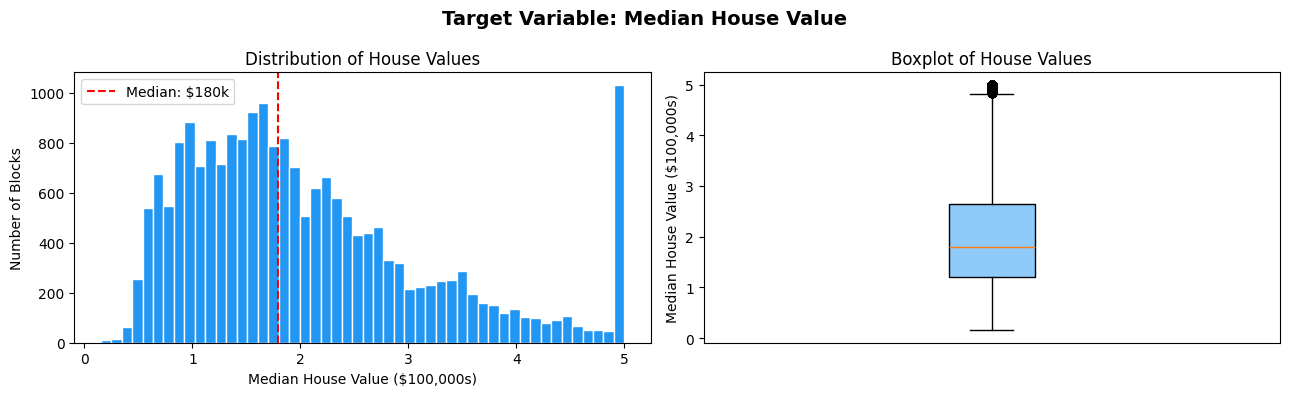

Mean:   $206.9k
Median: $179.7k
Std:    $115.4k


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: Histogram of house prices
axes[0].hist(y, bins=50, color='#2196F3', edgecolor='white')
axes[0].axvline(y.median(), color='red', linestyle='--', label=f'Median: ${y.median()*100:.0f}k')
axes[0].set_title('Distribution of House Values')
axes[0].set_xlabel('Median House Value ($100,000s)')
axes[0].set_ylabel('Number of Blocks')
axes[0].legend()

# Right: Boxplot to see spread and outliers
axes[1].boxplot(y, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#90CAF9'))
axes[1].set_title('Boxplot of House Values')
axes[1].set_ylabel('Median House Value ($100,000s)')
axes[1].set_xticks([])

plt.suptitle('Target Variable: Median House Value', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mean:   ${y.mean()*100:.1f}k")
print(f"Median: ${y.median()*100:.1f}k")
print(f"Std:    ${y.std()*100:.1f}k")

### 2c. Which Features Correlate Most With Price?

**Correlation** tells us how strongly two variables move together. For a regression model, features that are highly correlated with the target are likely to be the most predictive.

The most important column to look at is `HouseValue` — especially which features have the strongest positive or negative correlation with it.

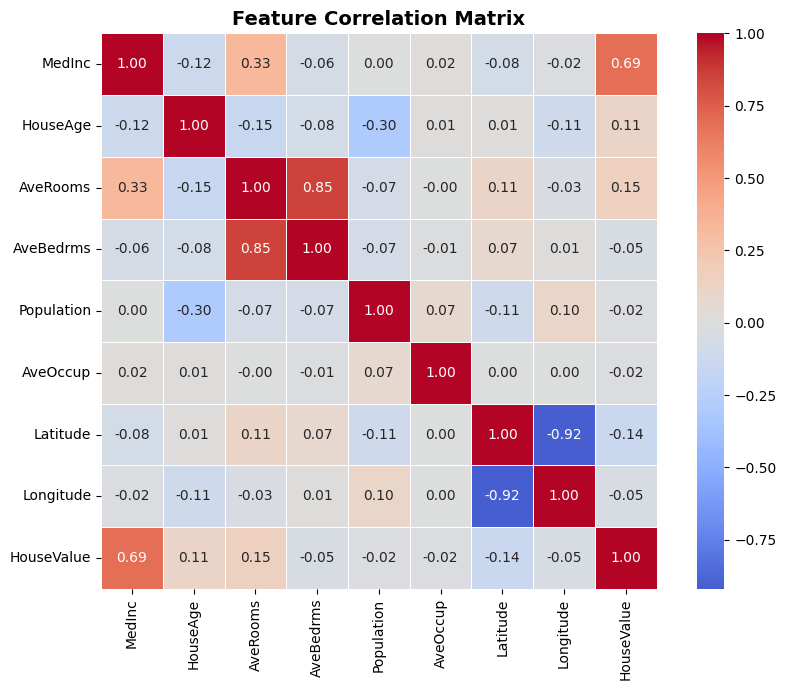

In [5]:
# Combine X and y into one DataFrame for correlation analysis
df_corr = X.copy()
df_corr['HouseValue'] = y

plt.figure(figsize=(9, 7))
corr = df_corr.corr().round(2)
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2d. Top Predictor: Income vs House Price

From the correlation matrix, `MedInc` (median income) is the strongest predictor of house value. A scatter plot lets us see this relationship directly — and preview how well a linear model will fit.

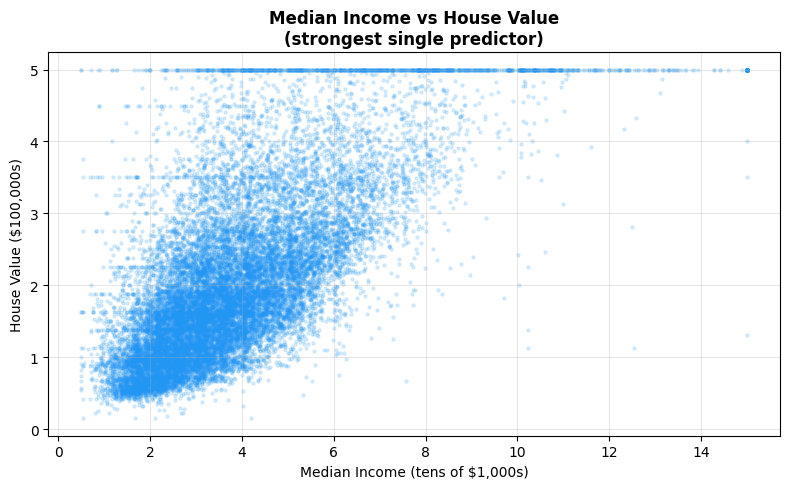

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(X['MedInc'], y, alpha=0.15, s=5, color='#2196F3')
plt.xlabel('Median Income (tens of $1,000s)')
plt.ylabel('House Value ($100,000s)')
plt.title('Median Income vs House Value\n(strongest single predictor)', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 3: Train / Test Split

We split the data so the model trains on one set and is evaluated on a separate set it has **never seen**. This simulates deploying the model on real new houses.

| Split | Size | Purpose |
|---|---|---|
| **Training set** | 80% (16,512 rows) | The model learns from this |
| **Test set** | 20% (4,128 rows) | We measure real-world performance here |

> **Unlike classification**, we do **not** need `stratify=y` here because the target is continuous — there are no discrete classes to preserve.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   # 20% held out for testing
    random_state=42  # Fixed seed for reproducibility
)

print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")

Training set:  16,512 rows
Test set:      4,128 rows


---
## Step 4: Train a Linear Regression Model

### How does Linear Regression work?

Linear Regression finds the best-fit **straight line** (or hyperplane in multiple dimensions) through the data. It learns a **coefficient (weight)** for each feature:

```
HouseValue = w₁×MedInc + w₂×HouseAge + w₃×AveRooms + ... + w₈×Longitude + b
```

Where:
- **w₁, w₂, ..., w₈** are the coefficients (learned from data)
- **b** is the intercept (baseline value when all features = 0)

### How are coefficients found?

The model minimises **Mean Squared Error (MSE)** — the average of the squared differences between predicted and actual values. Squaring penalises large errors more than small ones.

```
MSE = (1/n) × Σ (actual − predicted)²
```

### Does Linear Regression need feature scaling?

Technically **no** — unlike Logistic Regression, the ordinary least squares solver used here does not require it. However, scaling makes the coefficients **comparable in magnitude**, which helps with interpretation. We skip it here for simplicity.

In [8]:
from sklearn.linear_model import LinearRegression

# Instantiate and train the model
# .fit() solves for the optimal coefficients using ordinary least squares
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model trained successfully")
print(f"Number of coefficients learned: {len(model.coef_)}")
print(f"Intercept (b): {model.intercept_:.4f}")

✅ Model trained successfully
Number of coefficients learned: 8
Intercept (b): -37.0233


In [16]:
# Build a clean coefficient table
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("Model Coefficients (sorted):")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {model.intercept_:.4f}")

Model Coefficients (sorted):
   Feature  Coefficient
 AveBedrms     0.783145
    MedInc     0.448675
  HouseAge     0.009724
Population    -0.000002
  AveOccup    -0.003526
  AveRooms    -0.123323
  Latitude    -0.419792
 Longitude    -0.433708

Intercept: -37.0233


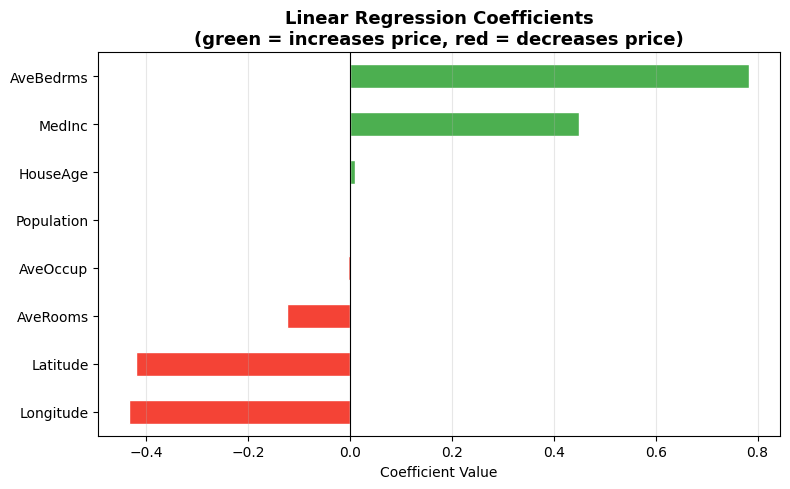

In [17]:
# Visualise coefficients as a horizontal bar chart
coef_sorted = pd.Series(model.coef_, index=X.columns).sort_values()

colors = ['#F44336' if c < 0 else '#4CAF50' for c in coef_sorted]

plt.figure(figsize=(8, 5))
coef_sorted.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression Coefficients\n(green = increases price, red = decreases price)',
          fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Interpret the Model Coefficients

### What does each coefficient mean?

In Linear Regression, each coefficient tells us:

> *"Holding all other features constant, a one-unit increase in this feature changes the predicted house value by [coefficient × $100,000]."*

For example, if the coefficient for `MedInc` is **+0.45**, it means:
- A 1-unit increase in median income (i.e. +$10,000/yr)
- Is associated with a +$45,000 increase in predicted house value

**Important caveat:** Because features are on different scales (income in tens of thousands, latitude in degrees), raw coefficient magnitudes are not directly comparable. For true importance ranking, you would need to scale features first — but the sign (positive/negative) is always meaningful.

| Sign | Meaning |
|---|---|
| **Positive** | Higher value of this feature → higher predicted price |
| **Negative** | Higher value of this feature → lower predicted price |

---
## Step 5: Predict on a Single Data Point

Before evaluating on the full test set, it's good practice to **manually test one prediction** and verify it makes intuitive sense.

We use the borrower at index 2 from the original dataset:

| Feature | Value | Meaning |
|---|---|---|
| MedInc | 7.26 | High-income neighbourhood (~$72,600/yr) |
| HouseAge | 52 | Older housing stock |
| AveRooms | 8.29 | Spacious homes |
| AveBedrms | 1.07 | ~1 bedroom per room |
| Population | 496 | Small block |
| AveOccup | 2.80 | ~3 people per household |
| Latitude | 37.85 | San Francisco Bay Area |
| Longitude | -122.24 | Oakland/Berkeley area |

> **What would you expect?** High income + Bay Area location → likely a high-value property.

In [9]:
# Single data point — must be passed as a list-of-lists (2D shape)
sample = [[7.2574, 52.0, 8.288136, 1.073446, 496.0, 2.802260, 37.85, -122.24]]
sample_df = pd.DataFrame(sample, columns=X.columns)

prediction = model.predict(sample_df)

print(f"Predicted house value: ${prediction[0]*100:.1f}k")
print(f"Actual house value:    ${y[2]*100:.1f}k")  # Actual value from the dataset

Predicted house value: $367.4k
Actual house value:    $352.1k


---
## Step 6: Evaluate on the Full Test Set

### Regression Evaluation Metrics

Unlike classification (where we count right/wrong), regression measures **how far off** predictions are on average.

| Metric | Formula | What it means | Units |
|---|---|---|---|
| **MAE** | mean(\|actual − predicted\|) | Average absolute error — easy to interpret | Same as target ($100k) |
| **MSE** | mean((actual − predicted)²) | Penalises large errors more heavily | Squared ($100k)² |
| **RMSE** | √MSE | Same units as target — most commonly reported | Same as target ($100k) |
| **R²** | 1 − SS_res/SS_tot | % of variance explained by the model | 0 to 1 (higher = better) |

### Interpreting R²

| R² | Interpretation |
|---|---|
| 1.0 | Perfect fit — model explains all variance |
| 0.6–0.8 | Good — typical for real-world regression |
| 0.0 | Model is no better than predicting the mean |
| < 0.0 | Model is worse than predicting the mean |

### Which metric matters most?

In real estate pricing:
- **MAE** is most intuitive: *"On average, our estimate is off by $X"*
- **RMSE** is more sensitive to large errors — important if pricing errors on expensive homes are costly
- **R²** tells the bank: *"Our model explains X% of house price variation — the rest is unexplained noise"*

In [10]:
# First: compare predictions vs actuals on the first 3 test samples
y_pred = model.predict(X_test)

print("--- First 3 Test Samples ---")
comparison = pd.DataFrame({
    'Actual ($100k)':    y_test[:3].values,
    'Predicted ($100k)': y_pred[:3].round(2),
    'Error ($100k)':     (y_test[:3].values - y_pred[:3]).round(2)
})
print(comparison.to_string(index=False))

--- First 3 Test Samples ---
 Actual ($100k)  Predicted ($100k)  Error ($100k)
        0.47700               0.72          -0.24
        0.45800               1.76          -1.31
        5.00001               2.71           2.29


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=== Model Performance on Test Set ===")
print(f"MAE:      {mae:.4f}  → avg error of ${mae*100:.1f}k per prediction")
print(f"MSE:      {mse:.4f}")
print(f"RMSE:     {rmse:.4f}  → typical error of ${rmse*100:.1f}k per prediction")
print(f"R² Score: {r2:.4f}  → model explains {r2*100:.1f}% of house price variation")

=== Model Performance on Test Set ===
MAE:      0.5332  → avg error of $53.3k per prediction
MSE:      0.5559
RMSE:     0.7456  → typical error of $74.6k per prediction
R² Score: 0.5758  → model explains 57.6% of house price variation


---
## Step 7: Visualise Predictions

### 7a. Actual vs Predicted Plot

The most intuitive way to evaluate a regression model is to plot **actual vs predicted values**.

- **Perfect model** → all points fall exactly on the red diagonal line
- **Points above the line** → model underestimated (predicted too low)
- **Points below the line** → model overestimated (predicted too high)
- **Spread around the line** → shows where the model struggles

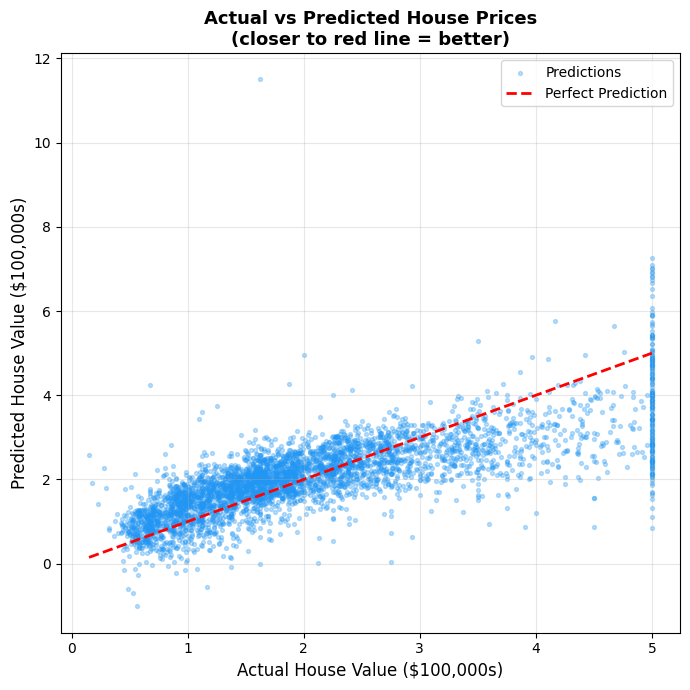

In [12]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, s=8, color='#2196F3', label='Predictions')

# Perfect prediction line: if actual == predicted, all points sit on this
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual House Value ($100,000s)', fontsize=12)
plt.ylabel('Predicted House Value ($100,000s)', fontsize=12)
plt.title('Actual vs Predicted House Prices\n(closer to red line = better)',
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7b. Residual Plot

A **residual** is the difference between the actual and predicted value:
```
Residual = Actual − Predicted
```

A good linear model should have residuals that are:
- **Randomly scattered** around zero (no systematic bias)
- **Roughly equal spread** across all predicted values (called homoscedasticity)

If you see a pattern (fan shape, curve), it means the linear model is missing something — the relationship may be non-linear.

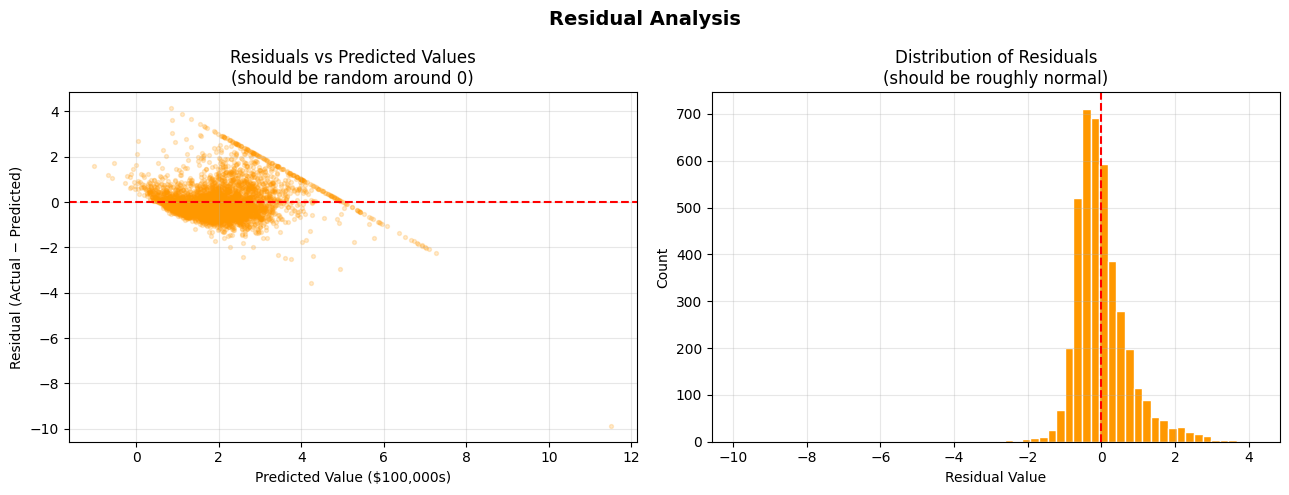

In [13]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.2, s=8, color='#FF9800')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Value ($100,000s)')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs Predicted Values\n(should be random around 0)')
axes[0].grid(alpha=0.3)

# Right: Distribution of residuals (should be roughly bell-shaped)
axes[1].hist(residuals, bins=60, color='#FF9800', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals\n(should be roughly normal)')
axes[1].grid(alpha=0.3)

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary

Here is everything you built in this notebook:

| Step | Code | What it does |
|---|---|---|
| **Load** | `fetch_california_housing()` | Loads a real dataset directly from sklearn |
| **Explore** | `.describe()`, correlation heatmap | Understands feature relationships |
| **Split** | `train_test_split(test_size=0.2)` | Separates training and evaluation data |
| **Train** | `LinearRegression().fit(X_train, y_train)` | Learns coefficients via least squares |
| **Predict** | `model.predict(sample)` | Applies learned formula to new data |
| **Evaluate** | MAE, RMSE, R² | Measures prediction accuracy |
| **Visualise** | Actual vs Predicted, Residual plots | Diagnoses model quality |
| **Interpret** | `model.coef_` | Understands what drives predictions |

### Key concepts to remember

- **Regression** predicts a continuous number; **classification** predicts a category
- **R²** tells you how much of the target's variance the model captures
- **RMSE** is the most practical error metric — it is in the same units as the target
- **Residual plots** reveal whether a linear model is appropriate or whether a more complex model is needed
- **Coefficients** show the direction and magnitude of each feature's effect — but only comparable in scale if features are standardised

### Suggested next steps
- Try adding `StandardScaler` before training and compare the coefficient magnitudes
- Try `Ridge` or `Lasso` regression (`from sklearn.linear_model import Ridge`) — regularised versions that reduce overfitting
- Try a `RandomForestRegressor` and compare its R² to Linear Regression on this same dataset
- Plot predictions on a map using latitude/longitude — do errors cluster geographically?